Install Libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [5]:
df = pd.read_csv("C:/Users/acer/Downloads/archive (2)/car data.csv")

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


Dataset Information

In [6]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       

Data Processing

In [11]:
encoder = LabelEncoder()

df['Fuel_Type'] = encoder.fit_transform(df['Fuel_Type'])
df['Selling_type'] = encoder.fit_transform(df['Selling_type'])
df['Transmission'] = encoder.fit_transform(df['Transmission'])

Feature Engineering

In [12]:
df['Car_Age'] = 2025 - df['Year']

df.drop('Year', axis=1, inplace=True)

print(df.head())

  Car_Name  Selling_Price  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0     ritz           3.35           5.59       27000          2             0   
1      sx4           4.75           9.54       43000          1             0   
2     ciaz           7.25           9.85        6900          2             0   
3  wagon r           2.85           4.15        5200          2             0   
4    swift           4.60           6.87       42450          1             0   

   Transmission  Owner  Car_Age  
0             1      0       11  
1             1      0       12  
2             1      0        8  
3             1      0       14  
4             1      0       11  


Data Visualization
Correlation Heatmap

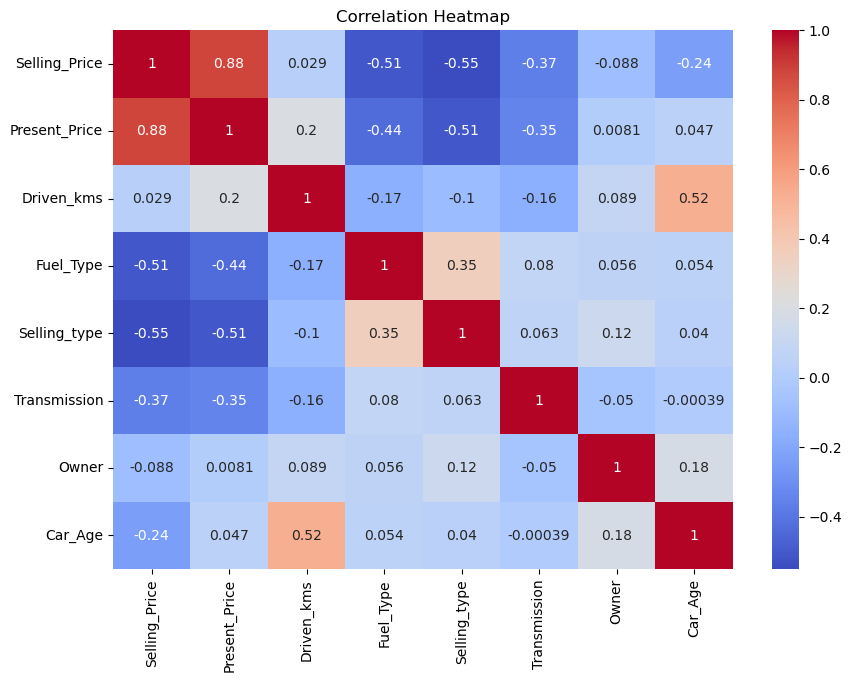

In [14]:
plt.figure(figsize=(10,7))
numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Car Age vs Selling Price

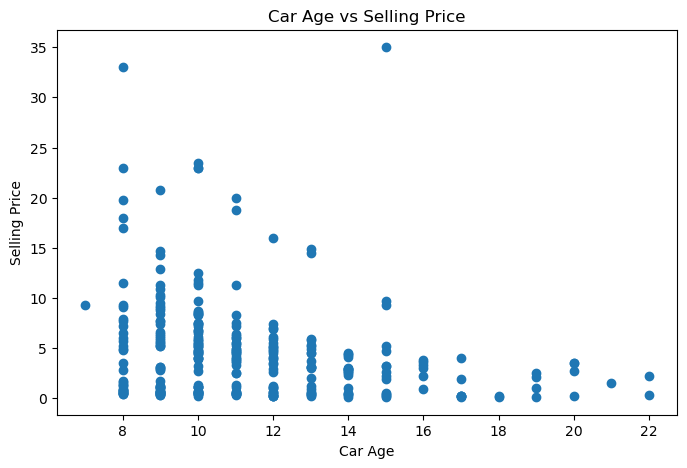

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['Car_Age'], df['Selling_Price'])
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")
plt.show()

Split Features and Target

In [20]:
numeric_df=df.select_dtypes(include=['number'])
X = numeric_df.drop('Selling_Price', axis=1)

y = numeric_df['Selling_Price']

Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Train Machine Learning Model

In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predictions

In [23]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[ 2.96562958  8.30085782  6.05782751 -1.46736816  9.25705687]


Model Evaluation

In [24]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1.221932362175384
MSE : 3.5315798889686314
RMSE : 1.879249820797818
R2 Score : 0.846690241966383


Actual vs Predicted Graph

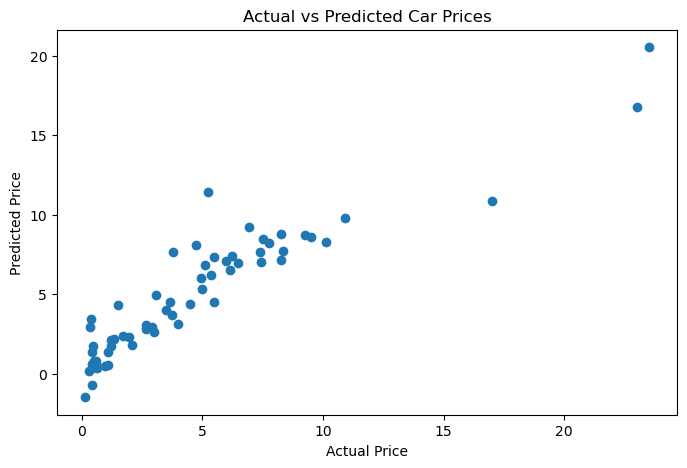

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

Predict New Car Price

In [28]:
sample_data = X.iloc[[0]]
prediction = model.predict(sample_data)

print("Predicted Car Price =", prediction[0])

Predicted Car Price = 3.9640582081645706


Final Insights

In [29]:
print("\nPROJECT INSIGHTS")

print("1. Car age affects selling price significantly.")

print("2. Fuel type and transmission influence car price.")

print("3. Linear Regression successfully predicts car prices.")

print("4. Feature engineering improved model performance.")

print("5. Machine Learning helps automate price prediction.")


PROJECT INSIGHTS
1. Car age affects selling price significantly.
2. Fuel type and transmission influence car price.
3. Linear Regression successfully predicts car prices.
4. Feature engineering improved model performance.
5. Machine Learning helps automate price prediction.
